In [11]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from scipy.stats import pearsonr
from statsmodels.tsa.stattools import adfuller

MAX_LAG = 3
MAX_ACF_LAG = 36
LAG_CORR_ALPHA = 0.05

data = pd.read_csv("ex14.dat", sep=r"\s+")
# COLUMNS:
# "lnfuture": "log future price",
# "lnspot": "log spot price",
# "cost": "pct carry cost" (i.e. multiplied by 100)
data["futures_rets"] = data["lnfuture"].diff()
data["spot_rets"] = data["lnspot"].diff()
df = data[["futures_rets", "spot_rets", "cost"]].copy()
df["cost"] /= 100
df = df.dropna()
print(df)

      futures_rets  spot_rets     cost
1          0.00022    0.00005 -0.00165
2          0.00069    0.00007 -0.00165
3         -0.00023    0.00000 -0.00165
4          0.00000   -0.00007 -0.00165
5         -0.00011    0.00002 -0.00165
...            ...        ...      ...
7056       0.00023    0.00014  0.00000
7057       0.00011    0.00015  0.00000
7058       0.00011   -0.00007  0.00000
7059      -0.00022   -0.00011  0.00000
7060      -0.00023    0.00003  0.00000

[7060 rows x 3 columns]


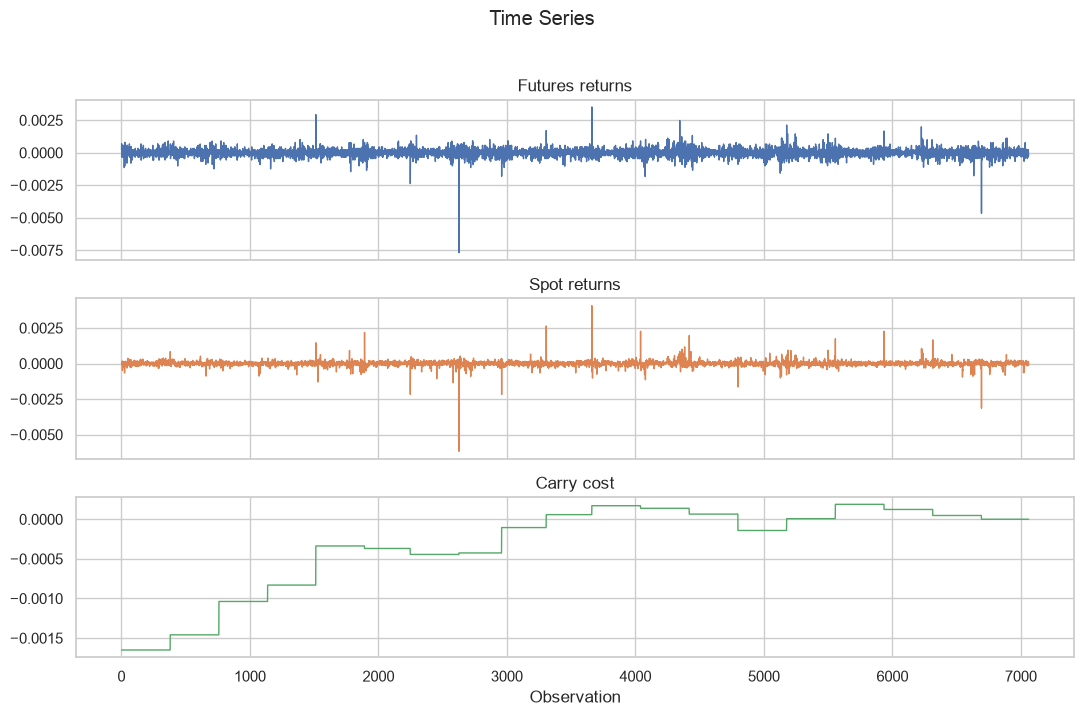

In [12]:
sns.set_theme(style="whitegrid")

axes = df.plot(
    subplots=True,
    figsize=(11, 7),
    title=["Futures returns", "Spot returns", "Carry cost"],
    legend=False,
    linewidth=1,
)
for ax in axes:
    ax.set_xlabel("Observation")
fig = axes[0].figure
fig.suptitle("Time Series", y=1.02)
fig.tight_layout()


Lag correlations: rows are current series, columns are lagged series
              futures_rets lag 0  spot_rets lag 0  cost lag 0  \
futures_rets              1.0000           0.3885      0.0004   
spot_rets                 0.3885           1.0000      0.0023   
cost                      0.0004           0.0023      1.0000   

              futures_rets lag 1  spot_rets lag 1  cost lag 1  \
futures_rets             -0.0330          -0.0078     -0.0013   
spot_rets                 0.1168           0.1385      0.0008   
cost                      0.0004           0.0021      0.9998   

              futures_rets lag 2  spot_rets lag 2  cost lag 2  \
futures_rets             -0.0038          -0.0308     -0.0010   
spot_rets                 0.1922           0.1215      0.0007   
cost                      0.0003           0.0020      0.9996   

              futures_rets lag 3  spot_rets lag 3  cost lag 3  
futures_rets              0.0118          -0.0029     -0.0014  
spot_rets          

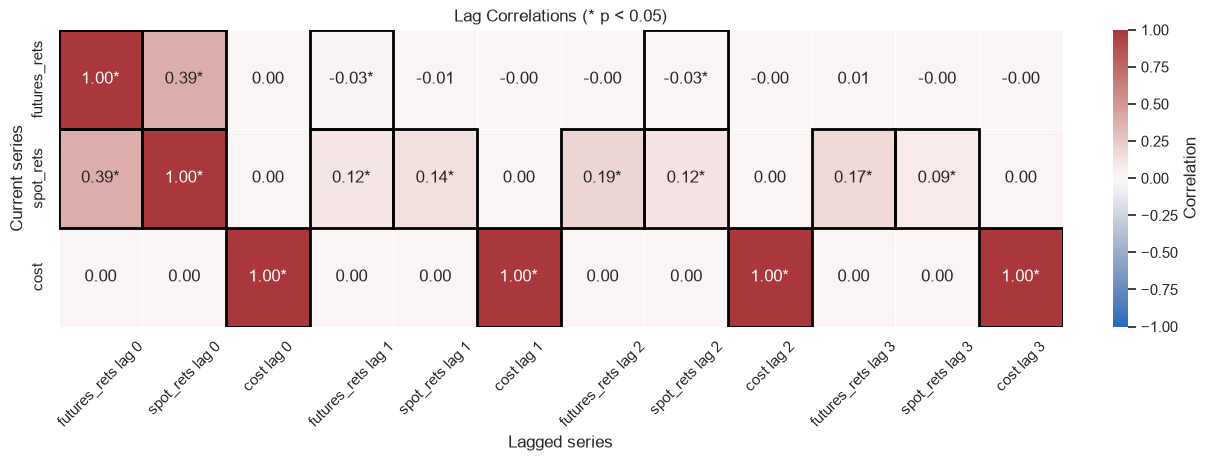

In [13]:
def lagged_pearsonr(current: pd.Series, lagged: pd.Series) -> tuple[float, float]:
    paired = pd.concat([current, lagged], axis=1).dropna()
    result = pearsonr(paired.iloc[:, 0], paired.iloc[:, 1])
    return result.statistic, result.pvalue # type: ignore


lag_correlation_results = {
    f"{lagged_col} lag {lag}": {
        current_col: lagged_pearsonr(df[current_col], df[lagged_col].shift(lag))
        for current_col in df.columns
    }
    for lag in range(MAX_LAG + 1)
    for lagged_col in df.columns
}

lag_correlations = pd.DataFrame(
    {
        lagged_col: {
            current_col: result[0] for current_col, result in current_results.items()
        }
        for lagged_col, current_results in lag_correlation_results.items()
    }
)
lag_correlation_pvalues = pd.DataFrame(
    {
        lagged_col: {
            current_col: result[1] for current_col, result in current_results.items()
        }
        for lagged_col, current_results in lag_correlation_results.items()
    }
)
significant_lag_correlations = lag_correlation_pvalues < LAG_CORR_ALPHA

print("\nLag correlations: rows are current series, columns are lagged series")
print(lag_correlations.round(4))
print(f"\nSignificant lag correlations at p < {LAG_CORR_ALPHA}")
print(lag_correlations.where(significant_lag_correlations).dropna(how="all", axis=1).round(4))

fig, ax = plt.subplots(figsize=(12, 4.5), constrained_layout=True)
lag_correlation_labels = lag_correlations.map(lambda value: f"{value:.2f}")
lag_correlation_labels = lag_correlation_labels.mask(
    significant_lag_correlations,
    lag_correlation_labels + "*",
)
sns.heatmap(
    lag_correlations,
    ax=ax,
    annot=lag_correlation_labels,
    fmt="",
    cmap="vlag",
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    cbar_kws={"label": "Correlation"},
)
for y, current_col in enumerate(lag_correlations.index):
    for x, lagged_col in enumerate(lag_correlations.columns):
        if significant_lag_correlations.loc[current_col, lagged_col]:
            ax.add_patch(
                plt.Rectangle( # type: ignore
                    (x, y),
                    1,
                    1,
                    fill=False,
                    edgecolor="black",
                    linewidth=2,
                )
            )

ax.set_title(f"Lag Correlations (* p < {LAG_CORR_ALPHA})")
ax.set_xlabel("Lagged series")
ax.set_ylabel("Current series")
ax.tick_params(axis="x", rotation=45)


Spot returns vs lagged futures returns
     correlation  p_value  significant
lag                                   
0         0.3885   0.0000         True
1         0.1168   0.0000         True
2         0.1922   0.0000         True
3         0.1747   0.0000         True
4         0.1206   0.0000         True
5         0.0952   0.0000         True
6         0.0620   0.0000         True
7         0.0711   0.0000         True
8         0.0405   0.0007         True
9         0.0280   0.0188         True
10        0.0396   0.0009         True
11        0.0183   0.1238        False
12        0.0344   0.0039         True
13        0.0125   0.2924        False
14        0.0107   0.3679        False
15       -0.0020   0.8665        False
16       -0.0030   0.8038        False
17        0.0222   0.0627        False
18        0.0281   0.0185         True
19        0.0067   0.5765        False
20       -0.0125   0.2954        False
21       -0.0026   0.8279        False
22       -0.0105   0.376

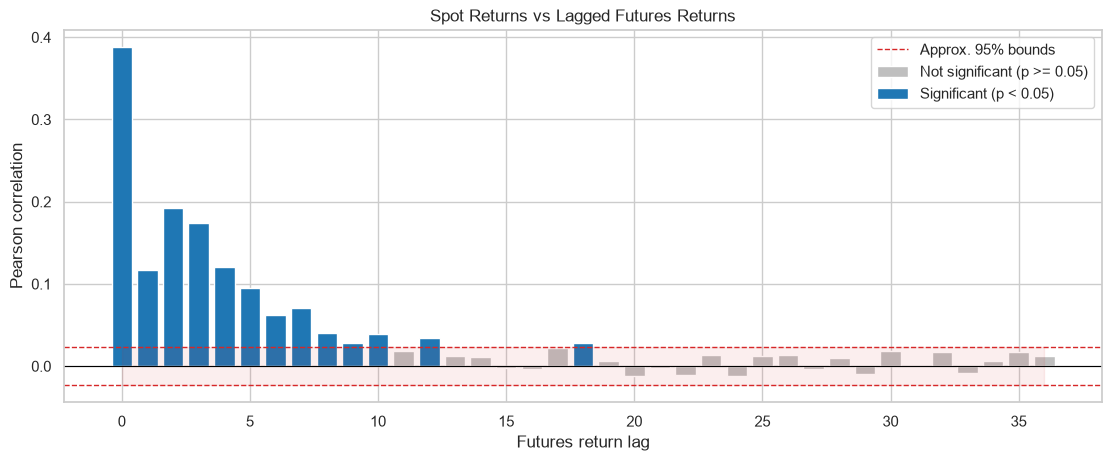

In [14]:
spot_futures_lag_results = [
    (lag, *lagged_pearsonr(df["spot_rets"], df["futures_rets"].shift(lag)))
    for lag in range(MAX_ACF_LAG + 1)
]
spot_futures_lags = pd.DataFrame(
    spot_futures_lag_results,
    columns=["lag", "correlation", "p_value"],
).set_index("lag")
spot_futures_lags["significant"] = spot_futures_lags["p_value"] < LAG_CORR_ALPHA
spot_futures_significance_level = 1.96 / (len(df) ** 0.5)

print("\nSpot returns vs lagged futures returns")
print(spot_futures_lags.round(4))

fig, ax = plt.subplots(figsize=(11, 4.5), constrained_layout=True)
significant_spot_futures_lags = spot_futures_lags["significant"]
ax.bar(
    spot_futures_lags.index[~significant_spot_futures_lags],
    spot_futures_lags.loc[~significant_spot_futures_lags, "correlation"],
    color="0.75",
    label=f"Not significant (p >= {LAG_CORR_ALPHA})",
)
ax.bar(
    spot_futures_lags.index[significant_spot_futures_lags],
    spot_futures_lags.loc[significant_spot_futures_lags, "correlation"],
    color="tab:blue",
    label=f"Significant (p < {LAG_CORR_ALPHA})",
)
ax.axhline(0, color="black", linewidth=0.8)
ax.axhline(
    spot_futures_significance_level,
    color="tab:red",
    linestyle="--",
    linewidth=1,
    label="Approx. 95% bounds",
)
ax.axhline(
    -spot_futures_significance_level,
    color="tab:red",
    linestyle="--",
    linewidth=1,
)
ax.fill_between(
    spot_futures_lags.index,
    -spot_futures_significance_level,
    spot_futures_significance_level,
    color="tab:red",
    alpha=0.08,
)
ax.set_title("Spot Returns vs Lagged Futures Returns")
ax.set_xlabel("Futures return lag")
ax.set_ylabel("Pearson correlation")
ax.legend()

 Linear regression on future and spot may work well with 0.4 correlation
 There's also an abnormal correlation with spot and lag 1 through 3 on future


Return autocorrelations
     futures_rets  spot_rets
lag                         
1         -0.0330     0.1385
2         -0.0038     0.1215
3          0.0118     0.0895
4         -0.0129     0.0817
5          0.0070     0.0459
6         -0.0049     0.0435
7          0.0034     0.0403
8         -0.0028     0.0300
9         -0.0128     0.0085
10         0.0017     0.0005
11         0.0047     0.0278
12        -0.0025     0.0054
13        -0.0064     0.0028
14        -0.0036     0.0271
15         0.0139     0.0091
16        -0.0039    -0.0018
17         0.0099    -0.0092
18        -0.0174     0.0137
19        -0.0069    -0.0067
20         0.0002    -0.0198
21         0.0059    -0.0205
22        -0.0049     0.0114
23         0.0164     0.0167
24         0.0001    -0.0079
25         0.0021    -0.0066
26        -0.0013     0.0086
27         0.0001     0.0051
28         0.0311     0.0182
29        -0.0181     0.0091
30         0.0083     0.0103
31         0.0140    -0.0021
32        -0.0109 

Text(0.5, 0, 'Lag')

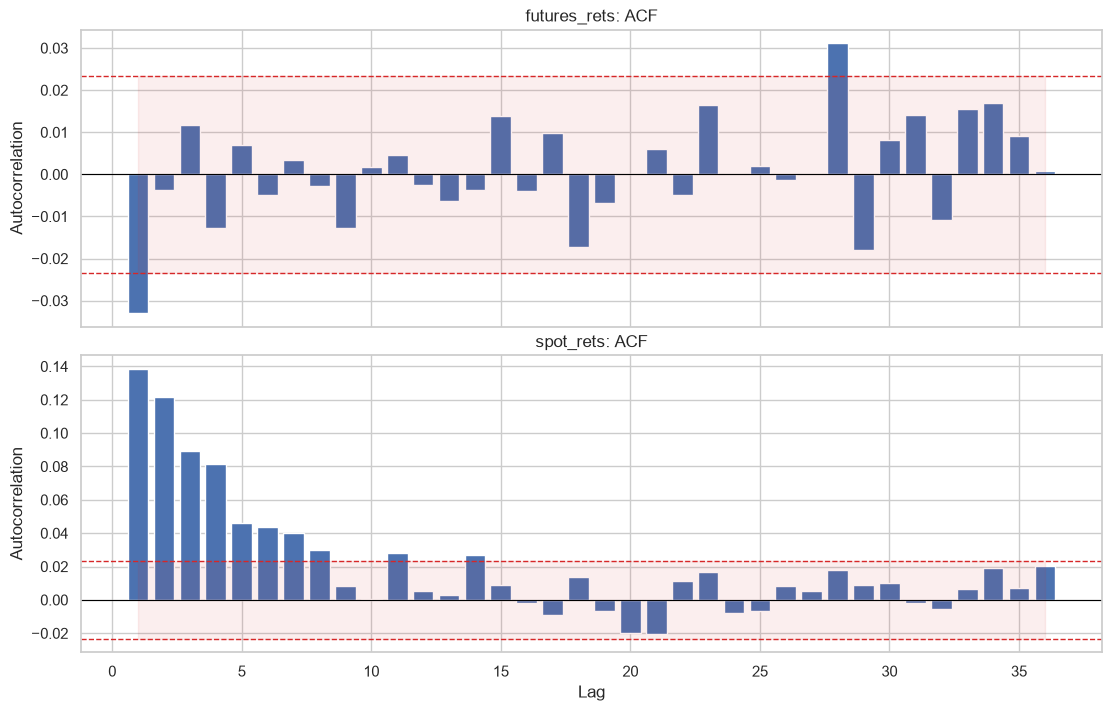

In [15]:
return_columns = ["futures_rets", "spot_rets"]
acf_lags = range(1, MAX_ACF_LAG + 1)
acf_significance_level = 1.96 / (len(df) ** 0.5)

return_acfs = pd.DataFrame(
    {
        column: [df[column].autocorr(lag=lag) for lag in acf_lags]
        for column in return_columns
    },
    index=pd.Index(acf_lags, name="lag"),
)

print("\nReturn autocorrelations")
print(return_acfs.round(4))
print(f"\nApprox. 95% ACF significance bounds: +/-{acf_significance_level:.4f}")

fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True, constrained_layout=True)
for ax, column in zip(axes, return_columns):
    ax.bar(return_acfs.index, return_acfs[column].to_numpy())
    ax.axhline(0, color="black", linewidth=0.8)
    ax.axhline(acf_significance_level, color="tab:red", linestyle="--", linewidth=1)
    ax.axhline(-acf_significance_level, color="tab:red", linestyle="--", linewidth=1)
    ax.fill_between(
        return_acfs.index,
        -acf_significance_level,
        acf_significance_level,
        color="tab:red",
        alpha=0.08,
    )
    ax.set_title(f"{column}: ACF")
    ax.set_ylabel("Autocorrelation")
axes[-1].set_xlabel("Lag")

In [16]:
adf_results = pd.DataFrame(
    {
        column: {
            "adf_statistic": result[0],
            "p_value": result[1],
            "used_lags": result[2],
            "n_observations": result[3],
            "stationary_at_5pct": result[1] < 0.05,
        }
        for column in return_columns
        for result in [adfuller(df[column], autolag="AIC")]
    }
).T

print("\nAugmented Dickey-Fuller stationarity tests")
print(adf_results.round(4))


Augmented Dickey-Fuller stationarity tests
             adf_statistic p_value used_lags n_observations stationary_at_5pct
futures_rets     -86.82252     0.0         0           7059               True
spot_rets       -26.742429     0.0         6           7053               True


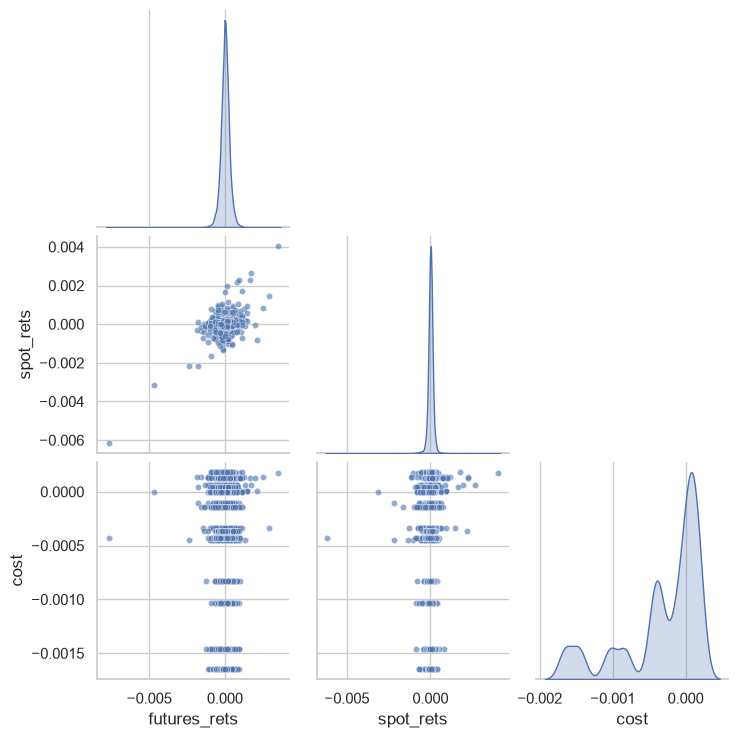

In [17]:
sns.pairplot(df, diag_kind="kde", corner=True, plot_kws={"alpha": 0.6, "s": 20})
plt.show()

maybe try linear reg of spot and futures